In [22]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
sns.set(style="whitegrid")

In [4]:
df = pd.read_csv("studentAssessment.csv")

In [5]:
df.head()

,id_assessment,id_student,date_submitted,is_banked,score
0,1752,11391,20.0,0,78
1,1753,11391,55.0,0,82
2,1754,11391,118.0,0,85
3,1755,11391,167.0,0,80
4,1756,11391,216.0,0,88


In [6]:
df.describe()

,id_assessment,id_student,date_submitted,is_banked,score
count,12.000000,12.00000,10.000000,12.0,12.000000
mean,1754.500000,19895.50000,115.200000,0.0,82.250000
std,1.783765,8882.66055,75.334513,0.0,4.351071
min,1752.000000,11391.00000,20.000000,0.0,75.000000
25%,1753.000000,11391.00000,55.000000,0.0,79.750000
50%,1754.500000,19895.50000,118.000000,0.0,81.500000
75%,1756.000000,28400.00000,167.000000,0.0,85.250000
max,1757.000000,28400.00000,216.000000,0.0,90.000000


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12 entries, 0 to 11
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   id_assessment   12 non-null     int64  
 1   id_student      12 non-null     int64  
 2   date_submitted  10 non-null     float64
 3   is_banked       12 non-null     int64  
 4   score           12 non-null     int64  
dtypes: float64(1), int64(4)
memory usage: 612.0 bytes


In [8]:
df.isnull().sum()

id_assessment     0
id_student        0
date_submitted    2
is_banked         0
score             0
dtype: int64

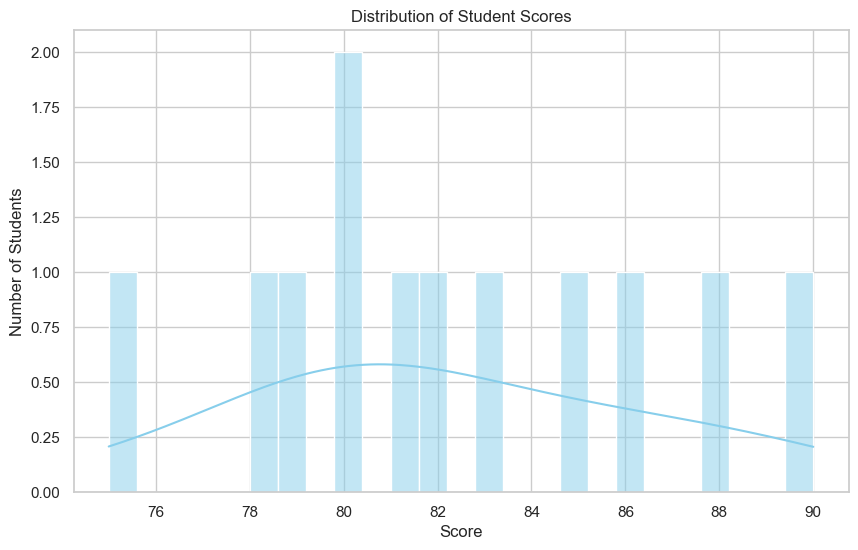

In [11]:
plt.figure(figsize=(10,6))

sns.histplot(
    data=df,
    x='score',
    bins=25,
    kde=True,
    color='skyblue'
)

plt.title("Distribution of Student Scores")
plt.xlabel("Score")
plt.ylabel("Number of Students")

plt.show()

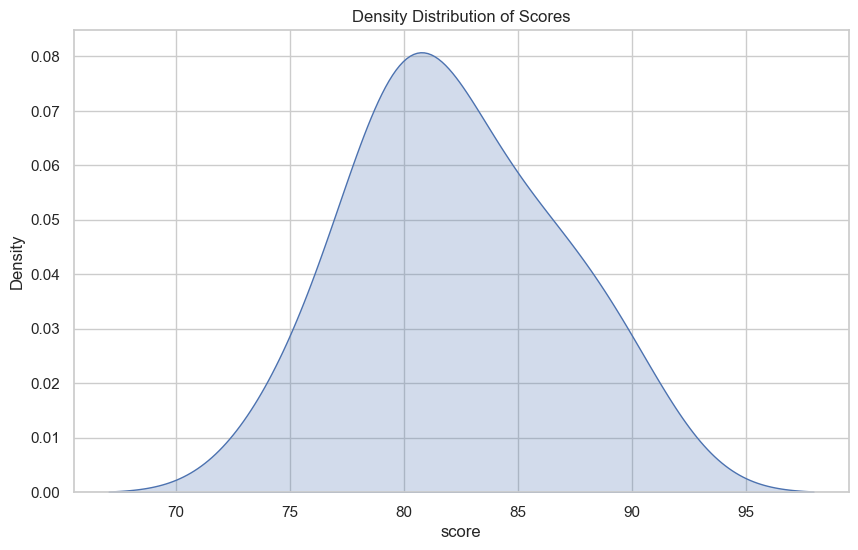

In [12]:
plt.figure(figsize=(10,6))

sns.kdeplot(
    data=df,
    x='score',
    fill=True
)

plt.title("Density Distribution of Scores")

plt.show()

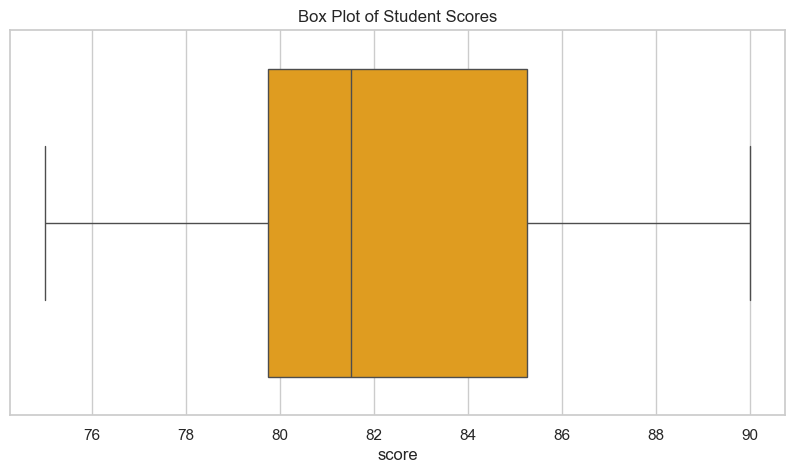

In [13]:
plt.figure(figsize=(10,5))

sns.boxplot(
    x=df['score'],
    color='orange'
)

plt.title("Box Plot of Student Scores")

plt.show()

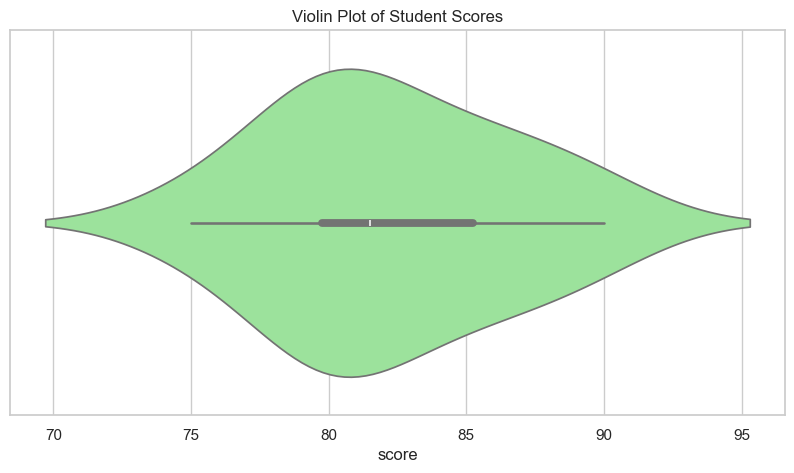

In [14]:
plt.figure(figsize=(10,5))

sns.violinplot(
    x=df['score'],
    color='lightgreen'
)

plt.title("Violin Plot of Student Scores")

plt.show()

In [15]:
Q1 = df['score'].quantile(0.25)
Q3 = df['score'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

print("Lower Limit :", lower)
print("Upper Limit :", upper)

Lower Limit : 71.5
Upper Limit : 93.5


In [17]:
outliers = df[
    (df['score'] < lower) |
    (df['score'] > upper)
]

outliers

,id_assessment,id_student,date_submitted,is_banked,score


In [18]:
print("Total Outliers:", len(outliers))

Total Outliers: 0


In [19]:
percentage = (len(outliers)/len(df))*100

print(f"Outlier Percentage: {percentage:.2f}%")

Outlier Percentage: 0.00%


In [21]:
outliers.to_csv("score_outliers.csv", index=False)

Exploratory Data Analysis Summary

Distribution

Most student scores lie between X–Y.
The distribution appears approximately normal/slightly skewed (depending on your output).

Outliers

Detected using the IQR method.
Total outliers: N
Outlier percentage: P%

Insights

Most students cluster around the median score.
A small number of unusually high or low scores exist.
These outliers may represent exceptional performers or students at academic risk.

In [30]:
df = pd.read_csv("studentAssessment.csv")

In [31]:
df.describe()

,id_assessment,id_student,date_submitted,is_banked,score
count,12.000000,12.00000,10.000000,12.0,12.000000
mean,1754.500000,19895.50000,115.200000,0.0,82.250000
std,1.783765,8882.66055,75.334513,0.0,4.351071
min,1752.000000,11391.00000,20.000000,0.0,75.000000
25%,1753.000000,11391.00000,55.000000,0.0,79.750000
50%,1754.500000,19895.50000,118.000000,0.0,81.500000
75%,1756.000000,28400.00000,167.000000,0.0,85.250000
max,1757.000000,28400.00000,216.000000,0.0,90.000000


In [32]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12 entries, 0 to 11
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   id_assessment   12 non-null     int64  
 1   id_student      12 non-null     int64  
 2   date_submitted  10 non-null     float64
 3   is_banked       12 non-null     int64  
 4   score           12 non-null     int64  
dtypes: float64(1), int64(4)
memory usage: 612.0 bytes


In [33]:
df.head()

,id_assessment,id_student,date_submitted,is_banked,score
0,1752,11391,20.0,0,78
1,1753,11391,55.0,0,82
2,1754,11391,118.0,0,85
3,1755,11391,167.0,0,80
4,1756,11391,216.0,0,88


In [37]:
student_vle = pd.read_csv("studentVle.csv")

student_assessment = pd.read_csv("studentAssessment.csv")

In [38]:
print(student_vle.columns)

print(student_assessment.columns)

Index(['code_module', 'code_presentation', 'id_student', 'id_site', 'date',
       'sum_click'],
      dtype='object')
Index(['id_assessment', 'id_student', 'date_submitted', 'is_banked', 'score'], dtype='object')


In [39]:
vle_summary = (
    student_vle
    .groupby("id_student")["sum_click"]
    .sum()
    .reset_index()
)

In [40]:
vle_summary

,id_student,sum_click
0,6516,2791
1,8462,656
2,11391,934
3,23629,161
4,23698,910
...,...,...
26069,2698251,1511
26070,2698257,758
26071,2698535,4241
26072,2698577,717


In [41]:
assessment_summary = (
    student_assessment
    .groupby("id_student")["score"]
    .mean()
    .reset_index()
)

In [42]:
assessment_summary

,id_student,score
0,11391,83.833333
1,28400,80.666667


In [43]:
merged_df = pd.merge(
    vle_summary,
    assessment_summary,
    on="id_student",
    how="inner"
)

In [44]:
merged_df

,id_student,sum_click,score
0,11391,934,83.833333
1,28400,1435,80.666667


In [45]:
merged_df.head()

,id_student,sum_click,score
0,11391,934,83.833333
1,28400,1435,80.666667


In [46]:
merged_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   id_student  2 non-null      int64  
 1   sum_click   2 non-null      int64  
 2   score       2 non-null      float64
dtypes: float64(1), int64(2)
memory usage: 180.0 bytes


In [47]:
merged_df.describe()

,id_student,sum_click,score
count,2.000000,2.000000,2.000000
mean,19895.500000,1184.500000,82.250000
std,12027.179241,354.260497,2.239171
min,11391.000000,934.000000,80.666667
25%,15643.250000,1059.250000,81.458333
50%,19895.500000,1184.500000,82.250000
75%,24147.750000,1309.750000,83.041667
max,28400.000000,1435.000000,83.833333


In [48]:
merged_df.isnull().sum()

id_student    0
sum_click     0
score         0
dtype: int64

In [50]:
merged_df.to_csv(
    "student_engagement.csv",
    index=False
)

In [51]:
correlation = merged_df["sum_click"].corr(
    merged_df["score"],
    method="pearson"
)

print("Pearson Correlation:", correlation)

Pearson Correlation: -0.9999999999999998


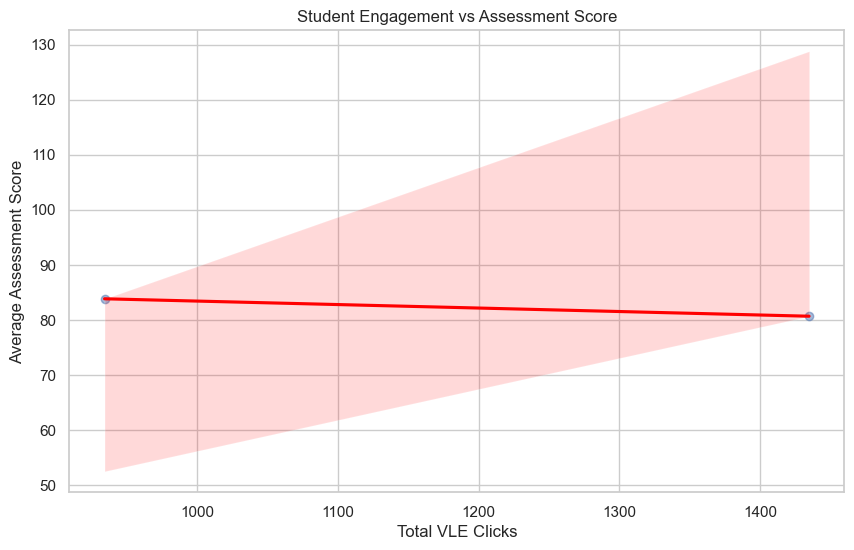

In [52]:
plt.figure(figsize=(10,6))

sns.regplot(
    data=merged_df,
    x="sum_click",
    y="score",
    scatter_kws={"alpha":0.5},
    line_kws={"color":"red"}
)

plt.title("Student Engagement vs Assessment Score")

plt.xlabel("Total VLE Clicks")

plt.ylabel("Average Assessment Score")

plt.show()

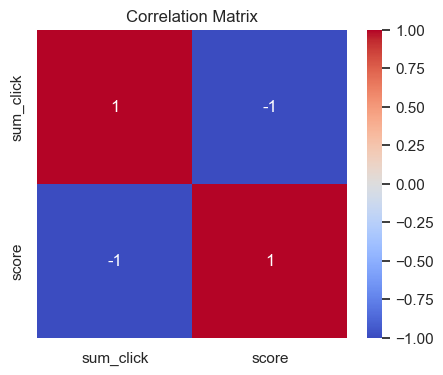

In [54]:
plt.figure(figsize=(5,4))

corr = merged_df[["sum_click","score"]].corr()

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    vmin=-1,
    vmax=1
)

plt.title("Correlation Matrix")

plt.show()

In [55]:
pd.merge(student_vle, student_assessment, on="id_student")

,code_module,code_presentation,id_student,id_site,date,sum_click,id_assessment,date_submitted,is_banked,score
0,AAA,2013J,28400,546652,-10,4,1752,20.0,0,75
1,AAA,2013J,28400,546652,-10,4,1753,55.0,0,80
2,AAA,2013J,28400,546652,-10,4,1754,118.0,0,79
3,AAA,2013J,28400,546652,-10,4,1755,167.0,0,81
4,AAA,2013J,28400,546652,-10,4,1756,216.0,0,83
...,...,...,...,...,...,...,...,...,...,...
3751,AAA,2013J,11391,546614,253,1,1753,55.0,0,82
3752,AAA,2013J,11391,546614,253,1,1754,118.0,0,85
3753,AAA,2013J,11391,546614,253,1,1755,167.0,0,80
3754,AAA,2013J,11391,546614,253,1,1756,216.0,0,88
